In [2]:
# Full LoRA
full_lora = 'results_Full_20260331_144413'

In [3]:
# Magnitude-based path
magnitude_path = './Magnitude-based'
fro_top_50 = 'results_fro_top_50.0%_20260327_152301'
fro_top_25 = 'results_fro_top_25.0%_20260310_182505'
l1_top_50 = 'results_l1_top_50.0%_20260303_142239'
l1_top_25 = 'results_l1_top_25.0%_20260310_190017'
spec_top_50 = 'results_spec_top_50.0%_20260303_144354'
spec_top_25 = 'results_spec_top_25.0%_20260308_145020'


In [4]:
# Gradient-based path
gradient_path = './Gradient-based'
top_50 = 'results_50%_20260308_163614'
top_25 = 'results_25%_20260307_170708'


In [5]:
# Layer-based path
layer_path = './Layer-based'
layer_5 = 'results_layer-based_20260310_200728'
layer_0 = 'results_layer-based_20260311_185448'
layer_bottom_2 = 'results_layer-based_20260311_191916'
layer_top_2 = 'results_layer-based_20260311_194406'
layer_1_3_5 = 'results_layer-based_20260311_202807'
layer_bottom_3 = 'results_layer-based_20260312_142107'
layer_top_3 = 'results_layer-based_20260312_130217'


In [6]:
import os
import json
import matplotlib.pyplot as plt

all_paths = {
    # Full LoRA
    "full_lora": f"./{full_lora}",
    
    # Layer
    "layer_5": f"{layer_path}/{layer_5}",
    "layer_0": f"{layer_path}/{layer_0}",
    "layer_bottom_2": f"{layer_path}/{layer_bottom_2}",
    "layer_top_2": f"{layer_path}/{layer_top_2}",
    "layer_1_3_5": f"{layer_path}/{layer_1_3_5}",
    "layer_bottom_3": f"{layer_path}/{layer_bottom_3}",
    "layer_top_3": f"{layer_path}/{layer_top_3}",

    # Gradient
    "top_50": f"{gradient_path}/{top_50}",
    "top_25": f"{gradient_path}/{top_25}",

    # Magnitude
    "fro_top_50": f"{magnitude_path}/{fro_top_50}",
    "fro_top_25": f"{magnitude_path}/{fro_top_25}",
    "l1_top_50": f"{magnitude_path}/{l1_top_50}",
    "l1_top_25": f"{magnitude_path}/{l1_top_25}",
    "spec_top_50": f"{magnitude_path}/{spec_top_50}",
    "spec_top_25": f"{magnitude_path}/{spec_top_25}",
}

In [7]:
data_cache = {}
for name, path in all_paths.items():
    json_file = os.path.join(path, "training_results_detailed_test.json")
    try:
        with open(json_file, "r") as f:
            data_cache[name] = json.load(f)
    except Exception as e:
        print(f"Skipping {json_file}: {e}")


In [8]:
def get_group_from_path(path):
    """Infer group name from the path string."""
    if "Layer-based" in path:
        return "Layer-based"
    elif "Gradient-based" in path:
        return "Gradient-based"
    elif "Magnitude-based" in path:
        return "Magnitude-based"
    else:
        return "Full LoRA"

color_map = {
    "Layer-based": "blue",
    "Gradient-based": "green",
    "Magnitude-based": "red",
    "Full LoRA": "orange"
}

def plot_key(data_cache, key, all_paths, desc, reverse=False, annotate=True):
    """Plot bar chart for a given key, colored by group inferred from path."""
    results = {name: d.get(key) for name, d in data_cache.items() if key in d}
    sorted_items = sorted(results.items(), key=lambda x: x[1], reverse=reverse)
    labels = [name for name, _ in sorted_items]
    values = [v for _, v in sorted_items]
    groups = [get_group_from_path(all_paths[name]) for name in labels]
    colors = [color_map[g] for g in groups]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, values, color=colors)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(desc)
    plt.title(f"{desc} Across Experiments")

    # Annotate values
    if annotate:
        for bar, val in zip(bars, values):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)

    # Legend with formatted labels, placed outside the plot
    legend_handles = []
    legend_labels = []
    for group, color in color_map.items():
        legend_handles.append(plt.Rectangle((0,0),1,1,color=color))
        legend_labels.append(group)
    plt.legend(legend_handles, legend_labels, title="Group",
               bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside

    plt.tight_layout()
    plt.show()


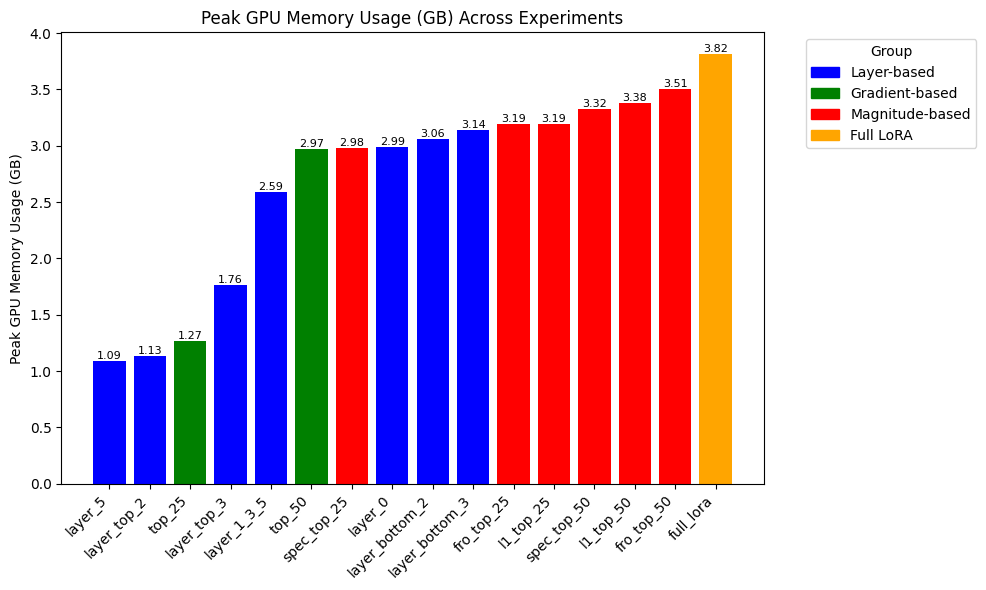

In [10]:
plot_key(data_cache, "gpu_memory_increase_during_training_gb", all_paths, "Peak GPU Memory Usage (GB)")

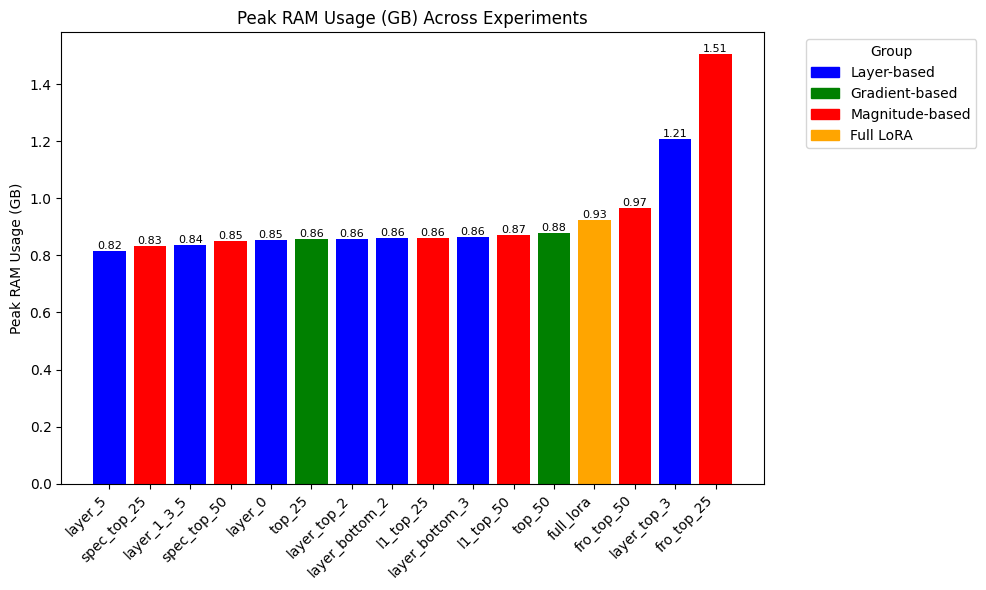

In [11]:
plot_key(data_cache, "ram_increase_during_training_gb", all_paths, "Peak RAM Usage (GB)")

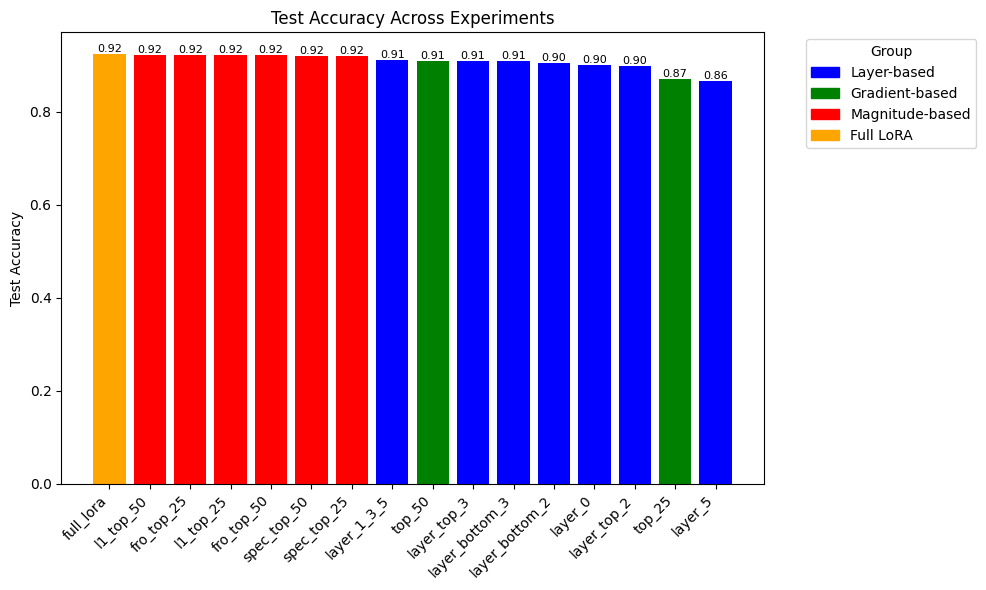

In [12]:
plot_key(data_cache, "test_accuracy", all_paths, "Test Accuracy", True)

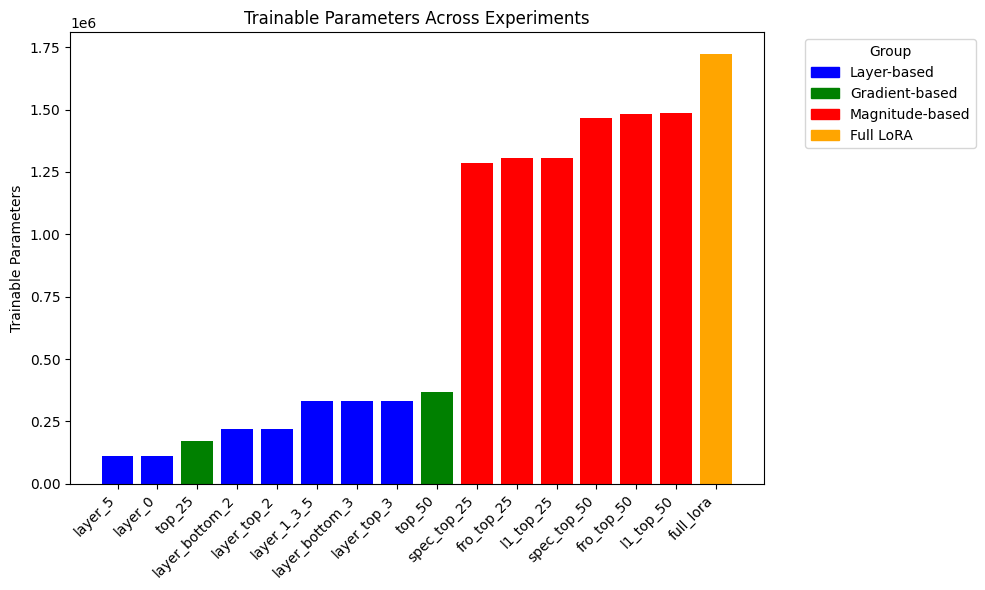

In [13]:
plot_key(data_cache, "trainable_parameters", all_paths, "Trainable Parameters", annotate=False)

In [1]:
import pandas as pd

# Load dataset from Hugging Face (train + test)
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
df_train = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["train"], lines=True)
df_test = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["test"], lines=True)

# Combine train and test for overall statistics
df = pd.concat([df_train, df_test], ignore_index=True)

# Compute word counts
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))
df['desc_word_count'] = df['description'].apply(lambda x: len(str(x).split()))

# Summary statistics for title and description
summary = df[['title_word_count', 'desc_word_count']].describe()

print(summary)

c:\Users\xavier\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


       title_word_count  desc_word_count
count     127600.000000    127600.000000
mean           6.783229        31.056771
std            2.088456         9.759814
min            1.000000         3.000000
25%            5.000000        25.000000
50%            7.000000        30.000000
75%            8.000000        36.000000
max           19.000000       173.000000


In [2]:
class_counts = df['label'].value_counts().sort_index()

# Map labels to categories
label_map = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}
class_distribution = pd.DataFrame({
    "Class Label": class_counts.index,
    "Category": [label_map[i] for i in class_counts.index],
    "Count": class_counts.values,
    "Percentage": (class_counts.values / len(df) * 100).round(2)
})

print(class_distribution)


   Class Label  Category  Count  Percentage
0            1     World  31900        25.0
1            2    Sports  31900        25.0
2            3  Business  31900        25.0
3            4  Sci/Tech  31900        25.0
